# Projet Deep Learning : Intel Image Classification
## Notebook Final (Version Améliorée)

Ce notebook présente une approche de bout en bout pour classifier des images de paysages naturels (`Intel Image Classification`). Il est configuré pour s'exécuter sur **Google Colab** en récupérant les données directement depuis **Google Drive**.

### Structure du projet :
1. **Connexion au Google Drive** et configuration des chemins d'accès.
2. **Pipeline de données complet** (chargement, normalisation ImageNet, augmentation de données, split train/val).
3. **Abstraction PyTorch Lightning** pour un code propre, modulaire et reproductible.
4. **Comparaison d'architectures** : Un `ImprovedCNN` (conçu de zéro, 4 blocs) vs. `ResNet18` (Fine-Tuning complet).
5. **Suivi des métriques & Entraînement** (Early Stopping, Learning Rate Scheduler, epochs suffisantes).
6. **Interprétation avancée des résultats** (Matrice de confusion, rapport de classification, courbes ROC et cartes d'activation).

### Améliorations par rapport à la version précédente :
- `ImprovedCNN` : 4 blocs convolutifs au lieu de 3, mieux adapté à des images 150×150
- `ResNet18` : fine-tuning complet avec LR différentiel (backbone + tête) au lieu du backbone gelé
- Ajout d'un split train/val explicite (80/20) sur le jeu d'entraînement
- Augmentation de données enrichie (RandomResizedCrop, perspective)
- `max_epochs=25` avec Early Stopping — permet une convergence réelle
- `batch_size=64` pour un meilleur gradient estimate


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0 — Installations, Imports et Connexion Google Drive

In [3]:
!pip install -q torch torchvision torchmetrics pytorch_lightning scikit-learn seaborn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 63.0 MB/s eta 0:00:00


In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from torchvision import transforms, models

SEED = 42
pl.seed_everything(SEED)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print("Environnement initialisé avec succès ✓")
print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible  : {torch.cuda.is_available()}")


INFO:lightning_fabric.utilities.seed:Seed set to 42


Environnement initialisé avec succès ✓
PyTorch version : 2.10.0+cu128
GPU disponible  : True


In [6]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

# ── Chemins source (Drive) ──────────────────────────────────────────
BASE_DATA_DIR = "/content/drive/MyDrive/deep_learning/image_dataset"
SRC_TRAIN = os.path.join(BASE_DATA_DIR, "seg_train", "seg_train")
SRC_TEST  = os.path.join(BASE_DATA_DIR, "seg_test",  "seg_test")

# Fallback si le sous-dossier doublé n'existe pas
if not os.path.exists(SRC_TRAIN):
    SRC_TRAIN = os.path.join(BASE_DATA_DIR, "seg_train")
    SRC_TEST  = os.path.join(BASE_DATA_DIR, "seg_test")

# ── Copie vers le stockage local Colab (SSD) ────────────────────────
DATA_DIR_TRAIN = "/content/dataset/seg_train"
DATA_DIR_TEST  = "/content/dataset/seg_test"

if not os.path.exists(DATA_DIR_TRAIN):
    print("Copie du dataset vers le stockage local... (1-3 min)")
    shutil.copytree(SRC_TRAIN, DATA_DIR_TRAIN)
    shutil.copytree(SRC_TEST,  DATA_DIR_TEST)
    print(f"✓ Train : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TRAIN))} images")
    print(f"✓ Test  : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TEST))} images")
else:
    print("✓ Dataset déjà copié localement.")

print("Classes :", sorted(os.listdir(DATA_DIR_TRAIN)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copie du dataset vers le stockage local... (1-3 min)
✓ Train : 14034 images
✓ Test  : 3000 images
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 1 — Pipeline Deep Learning (Data & Augmentation)

L'augmentation de données est enrichie par rapport à la version précédente : on ajoute un `RandomResizedCrop` qui simule différents niveaux de zoom, et une légère déformation de perspective. Ces transformations sont particulièrement utiles pour les paysages naturels où le même motif peut apparaître à différentes échelles.

Un **split train/val explicite (80/20)** est appliqué sur le jeu d'entraînement. Cela permet d'utiliser la validation pour le Early Stopping et le scheduler, sans jamais contaminer le jeu de test.


In [7]:
IMG_SIZE = 150

# Augmentation enrichie pour l'entraînement
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),       # légère suraille avant crop
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),# zoom variable
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pas d'augmentation pour val/test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class IntelImageDataset(Dataset):
    """Dataset personnalisé pour parser l'arborescence native des données Intel"""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


## 2 — Abstraction avec PyTorch Lightning

Le `LightningModule` est conservé à l'identique. La seule modification est dans `configure_optimizers` : on accepte maintenant un paramètre optionnel `param_groups` pour permettre des **learning rates différentiels** (backbone vs tête de classification) utilisés lors du fine-tuning de ResNet18.


In [8]:
class LitIntelClassifier(pl.LightningModule):
    def __init__(self, model_architecture, num_classes=6, lr=1e-3,
                 weight_decay=1e-4, lr_backbone=None):
        """
        lr_backbone : si fourni, applique un LR réduit au backbone (fine-tuning différentiel).
                      Sinon, un seul LR pour tout le modèle.
        """
        super().__init__()
        self.save_hyperparameters(ignore=['model_architecture'])
        self.model = model_architecture
        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc',  self.train_acc(logits, y), on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc',  self.val_acc(logits, y), on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.log('test_loss', self.criterion(logits, y), on_epoch=True)
        self.log('test_acc',  self.test_acc(logits, y), on_epoch=True)
        return {"logits": logits, "labels": y}

    def configure_optimizers(self):
        lr_bb = self.hparams.lr_backbone

        if lr_bb is not None and hasattr(self.model, 'backbone_params'):
            # LR différentiel : backbone avec LR réduit, tête avec LR normal
            param_groups = [
                {"params": self.model.backbone_params(), "lr": lr_bb},
                {"params": self.model.head_params(),     "lr": self.hparams.lr},
            ]
            optimizer = optim.AdamW(param_groups, weight_decay=self.hparams.weight_decay)
        else:
            optimizer = optim.AdamW(self.parameters(),
                                    lr=self.hparams.lr,
                                    weight_decay=self.hparams.weight_decay)

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.trainer.max_epochs if self.trainer else 25
        )
        return {"optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"}}


## 3 — Définition des Deux Architectures à Comparer

### Modèle 1 : `ImprovedCNN` (baseline from scratch)

Par rapport à la version précédente (`SimpleCNN`, 3 blocs, 32→64→128 filtres), on ajoute :
- **Un 4ème bloc convolutif** (256 filtres) pour mieux capturer les features de haut niveau sur des images 150×150
- **Un classifieur plus large** (256→128 au lieu de 128→64) pour plus de capacité de discrimination

### Modèle 2 : `ResNet18` avec Fine-Tuning complet

La différence clé avec la version précédente : le backbone n'est **plus gelé**. On dégèle tout le réseau et on applique un **learning rate différentiel** :
- Backbone pré-entraîné : LR = 1e-4 (petits ajustements pour ne pas détruire les features ImageNet)
- Tête de classification : LR = 1e-3 (apprentissage normal)

Cette stratégie exploite pleinement les poids pré-entraînés tout en les adaptant aux spécificités du dataset Intel (paysages naturels ≈ distribution ImageNet).


In [9]:
class ImprovedCNN(nn.Module):
    """
    CNN from scratch — 4 blocs convolutifs.
    Mieux adapté à des images 150x150 que le SimpleCNN à 3 blocs.
    Progression des filtres : 32 → 64 → 128 → 256
    """
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 150 → 75

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 75 → 37

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 37 → 18

            # Bloc 4 — ajout clé vs version précédente
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 18 → 9
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ResNetFineTune(nn.Module):
    """
    ResNet18 avec fine-tuning complet (backbone dégelé).
    Expose backbone_params() et head_params() pour le LR différentiel.

    Différence clé avec la version précédente :
    - freeze_backbone=True → tout gelé sauf la tête (feature extraction seulement)
    - Ici : tout dégelé, backbone entraîné avec LR réduit (1e-4)
    """
    def __init__(self, num_classes=6):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # On garde tout le backbone tel quel (aucun gel)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # tout sauf fc

        # Nouvelle tête de classification
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def backbone_params(self):
        return self.backbone.parameters()

    def head_params(self):
        return self.head.parameters()

    def forward(self, x):
        return self.head(self.backbone(x))


# Vérification des architectures
dummy = torch.randn(2, 3, 150, 150)
cnn  = ImprovedCNN()
rnet = ResNetFineTune()

print(f"ImprovedCNN   — sortie : {cnn(dummy).shape}  | params : {sum(p.numel() for p in cnn.parameters()):,}")
print(f"ResNetFineTune— sortie : {rnet(dummy).shape} | params : {sum(p.numel() for p in rnet.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


ImprovedCNN   — sortie : torch.Size([2, 6])  | params : 423,046
ResNetFineTune— sortie : torch.Size([2, 6]) | params : 11,309,382


## 4 — Entraînement et Courbes d'Apprentissage

Les changements principaux :
- **`max_epochs=25`** avec Early Stopping (patience=5) : suffisant pour converger sans être excessif
- **`batch_size=64`** : meilleure estimation du gradient que batch_size=32
- **`CSVLogger`** au lieu de TensorBoardLogger : plus simple à lire directement dans Colab
- Scheduler **CosineAnnealingLR** : décroissance douce du LR sur toute la durée de l'entraînement


In [10]:
def train_model(lit_model, model_name, train_loader, val_loader, max_epochs=25):
    logger = CSVLogger("logs/", name=model_name)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, mode="min", verbose=True),
        ModelCheckpoint(monitor="val_acc", filename="best-{epoch:02d}-{val_acc:.3f}",
                        mode="max", save_top_k=1)
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        logger=logger,
        callbacks=callbacks,
        log_every_n_steps=10,
    )

    trainer.fit(lit_model, train_loader, val_loader)
    return trainer


def plot_learning_curves(trainer, model_name="Modèle"):
    """Lit le CSV du logger et trace les courbes de loss et accuracy"""
    import pandas as pd
    metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")

    if not os.path.exists(metrics_path):
        print("Pas de métriques CSV disponibles.")
        return

    df = pd.read_csv(metrics_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Courbes d'Apprentissage — {model_name}", fontsize=13, fontweight='bold')

    # Loss
    train_loss = df[df['train_loss'].notna()][['epoch', 'train_loss']]
    val_loss   = df[df['val_loss'].notna()][['epoch', 'val_loss']]
    ax1.plot(train_loss['epoch'], train_loss['train_loss'], '-o', ms=4, label='Train Loss')
    ax1.plot(val_loss['epoch'],   val_loss['val_loss'],   '-o', ms=4, label='Val Loss')
    ax1.set_title('Évolution de la Perte (Loss)')
    ax1.set_xlabel('Époques')
    ax1.legend()

    # Accuracy
    train_acc = df[df['train_acc'].notna()][['epoch', 'train_acc']]
    val_acc   = df[df['val_acc'].notna()][['epoch', 'val_acc']]
    ax2.plot(train_acc['epoch'], train_acc['train_acc'], '-o', ms=4, label='Train Acc')
    ax2.plot(val_acc['epoch'],   val_acc['val_acc'],   '-o', ms=4, label='Val Acc')
    ax2.set_title('Évolution de la Précision (Accuracy)')
    ax2.set_xlabel('Époques')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_curves.png", dpi=120)
    plt.show()


## 5 — Évaluation Métrique et Interprétation Avancée (Matrices & Courbes ROC)

In [11]:
def evaluate_and_interpret(lit_model, test_loader, class_names, model_name="Modèle"):
    lit_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lit_model.to(device)

    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            logits = lit_model(x.to(device))
            probs  = F.softmax(logits, dim=1)
            preds  = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs   = np.array(all_probs)

    # 1. Matrice de Confusion
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matrice de Confusion — {model_name}')
    plt.ylabel('Classes Réelles')
    plt.xlabel('Classes Prédites')
    plt.tight_layout()
    plt.show()

    # 2. Rapport de Classification
    print(f"\n=== RAPPORT DE CLASSIFICATION — {model_name} ===")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    # 3. Courbes ROC Multi-classes (One-vs-Rest)
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_targets == i, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'Courbes ROC Multi-classes — {model_name}')
    plt.xlabel('Taux de Faux Positifs (FPR)')
    plt.ylabel('Taux de Vrais Positifs (TPR)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return all_preds, all_targets, all_probs


## 6 — Visualisation des Filtres Convolutifs (Cartes d'Activation)

In [12]:
def plot_feature_maps(model, sample_image, layer_index=0):
    """Affiche les premières activations de filtres pour analyser les motifs captés"""
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'features'):
            first_layer = model.features[layer_index]
            activation  = first_layer(sample_image.unsqueeze(0).to(next(model.parameters()).device))

            n_filters = min(activation.shape[1], 8)
            fig, axes = plt.subplots(2, 4, figsize=(12, 6))
            fig.suptitle(f"Cartes d'Activation — Couche {layer_index} (ImprovedCNN)")
            for i, ax in enumerate(axes.flat):
                if i < n_filters:
                    ax.imshow(activation[0, i].cpu().numpy(), cmap='viridis')
                ax.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print("Ce modèle n'expose pas de conteneur '.features' directement accessible.")


## 7 — Phase d'Exécution Globale (Entraînement & Évaluation)

### Split Train / Val

On découpe le jeu d'entraînement en 80% train / 20% val. Le jeu de test reste complètement séparé et n'est utilisé qu'en évaluation finale.


In [13]:
# ── Chargement des données ──────────────────────────────────────────────
full_train_set = IntelImageDataset(DATA_DIR_TRAIN, transform=train_transforms)
test_set       = IntelImageDataset(DATA_DIR_TEST,  transform=val_test_transforms)

# Split 80/20 train/val
val_size   = int(0.2 * len(full_train_set))
train_size = len(full_train_set) - val_size
train_set, val_set_raw = random_split(
    full_train_set, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Le val_set doit utiliser val_test_transforms (pas d'augmentation)
# On wrap le subset pour remplacer le transform
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img_path = self.subset.dataset.image_paths[self.subset.indices[idx]]
        label    = self.subset.dataset.labels[self.subset.indices[idx]]
        image    = Image.open(img_path).convert('RGB')
        return self.transform(image), label

val_set = TransformSubset(val_set_raw, val_test_transforms)

# DataLoaders — batch_size=64 (amélioration vs 32)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

classes = full_train_set.class_names
print(f"Train : {len(train_set)} | Val : {len(val_set)} | Test : {len(test_set)}")
print(f"Classes : {classes}")


Train : 11228 | Val : 2806 | Test : 3000
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


=== ENTRAÎNEMENT : IMPROVED CNN (4 blocs, from scratch) ===



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ImprovedCNN        │  423 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 423 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 423 K                                                                                                
Total estimated model params size (MB): 1.692                                                                      
Modules in train mode: 29                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.819
INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.819. Signaling Trainer to stop.


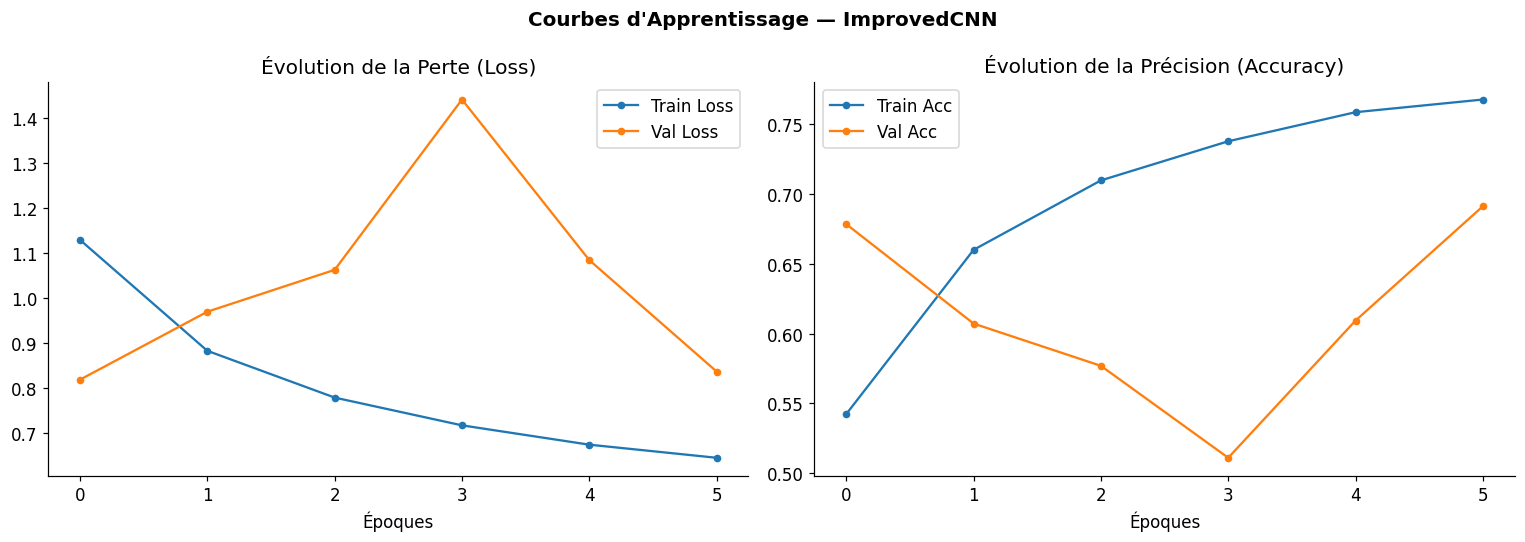


→ Évaluation finale sur le jeu de TEST :


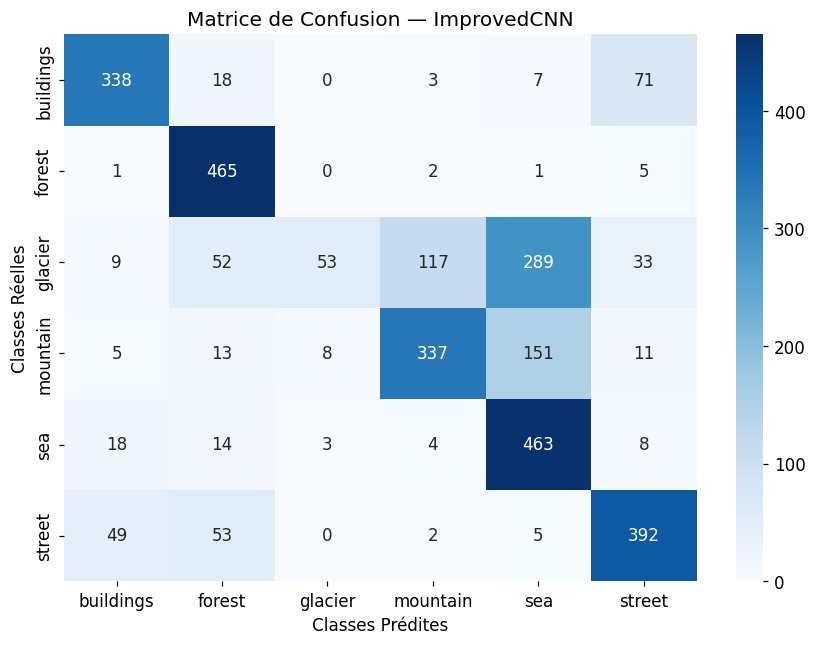


=== RAPPORT DE CLASSIFICATION — ImprovedCNN ===
              precision    recall  f1-score   support

   buildings       0.80      0.77      0.79       437
      forest       0.76      0.98      0.85       474
     glacier       0.83      0.10      0.17       553
    mountain       0.72      0.64      0.68       525
         sea       0.51      0.91      0.65       510
      street       0.75      0.78      0.77       501

    accuracy                           0.68      3000
   macro avg       0.73      0.70      0.65      3000
weighted avg       0.73      0.68      0.64      3000



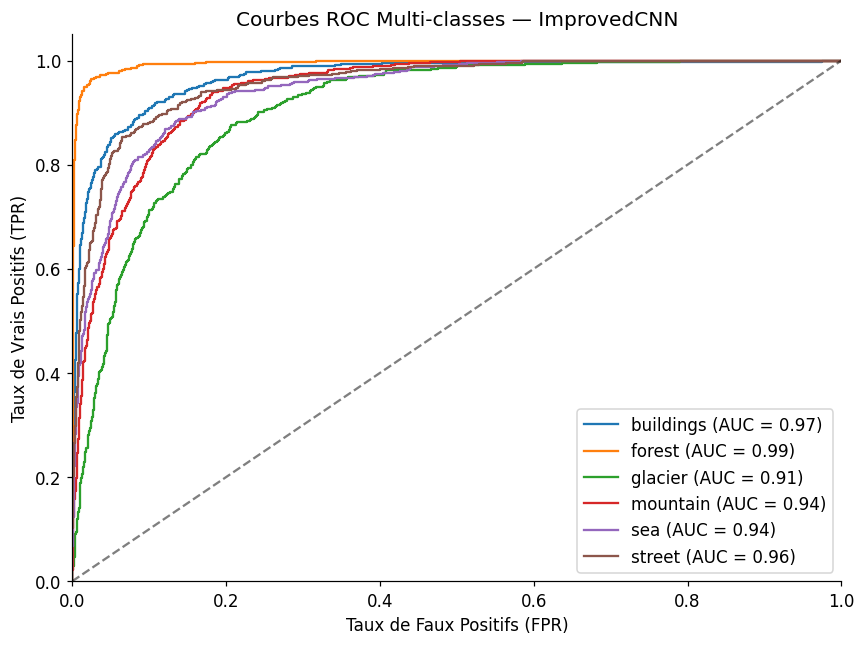

In [14]:
# ─────────────────────────────────────────────────────────────────────────
# EXPÉRIENCE 1 : ImprovedCNN (from scratch, 4 blocs)
# ─────────────────────────────────────────────────────────────────────────
print("=== ENTRAÎNEMENT : IMPROVED CNN (4 blocs, from scratch) ===\n")

cnn_net    = ImprovedCNN(num_classes=len(classes))
lit_cnn    = LitIntelClassifier(cnn_net, num_classes=len(classes), lr=1e-3, weight_decay=1e-4)

trainer_cnn = train_model(lit_cnn, "ImprovedCNN", train_loader, val_loader, max_epochs=25)

# Courbes d'apprentissage
plot_learning_curves(trainer_cnn, model_name="ImprovedCNN")

# Évaluation sur le jeu de test
print("\n→ Évaluation finale sur le jeu de TEST :")
preds_cnn, targets_cnn, probs_cnn = evaluate_and_interpret(lit_cnn, test_loader, classes, "ImprovedCNN")



=== ENTRAÎNEMENT : RESNET18 FINE-TUNING (backbone dégelé) ===

LR backbone : 1e-4  |  LR tête : 1e-3



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNetFineTune     │ 11.3 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.3 M                                                                                               
Total estimated model params size (MB): 45.238                                                                     
Modules in train mode: 78                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.284
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.064 >= min_delta = 0.0. New best score: 0.220
INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.220. Signaling Trainer to stop.


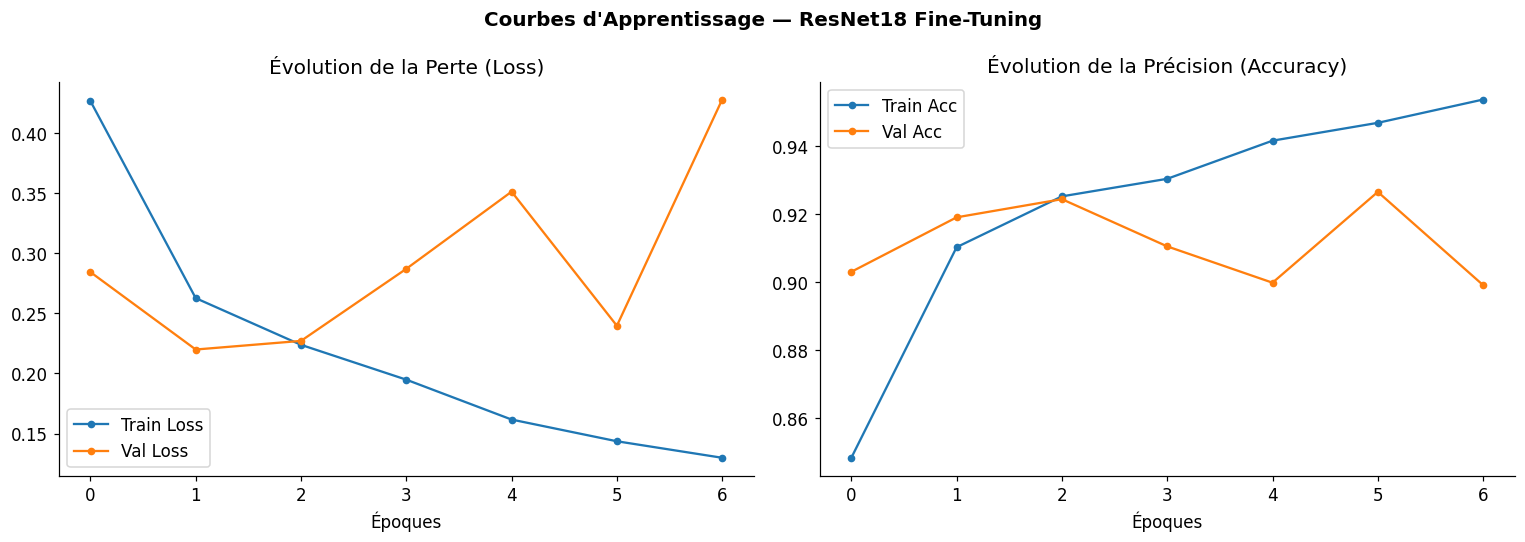


→ Évaluation finale sur le jeu de TEST :


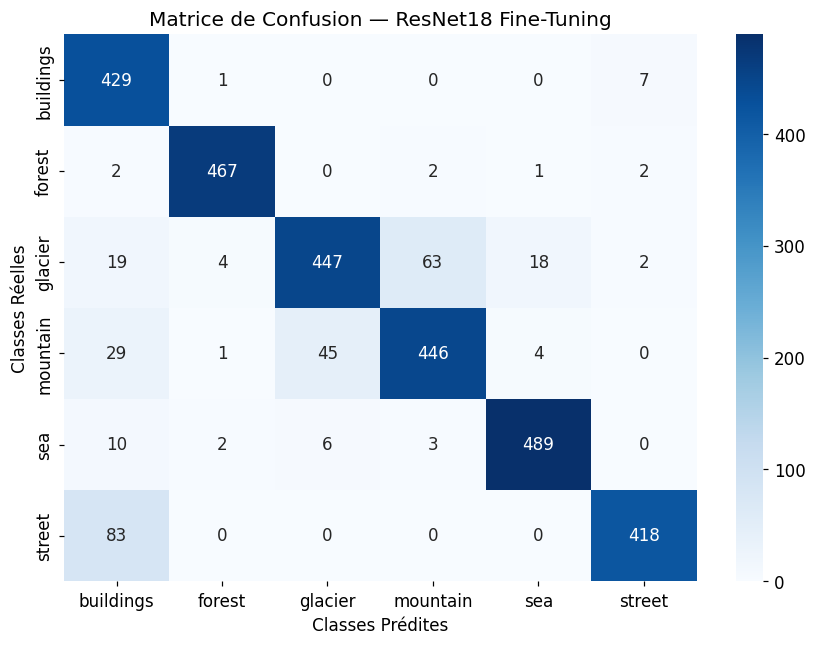


=== RAPPORT DE CLASSIFICATION — ResNet18 Fine-Tuning ===
              precision    recall  f1-score   support

   buildings       0.75      0.98      0.85       437
      forest       0.98      0.99      0.98       474
     glacier       0.90      0.81      0.85       553
    mountain       0.87      0.85      0.86       525
         sea       0.96      0.96      0.96       510
      street       0.97      0.83      0.90       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.91      0.90      0.90      3000



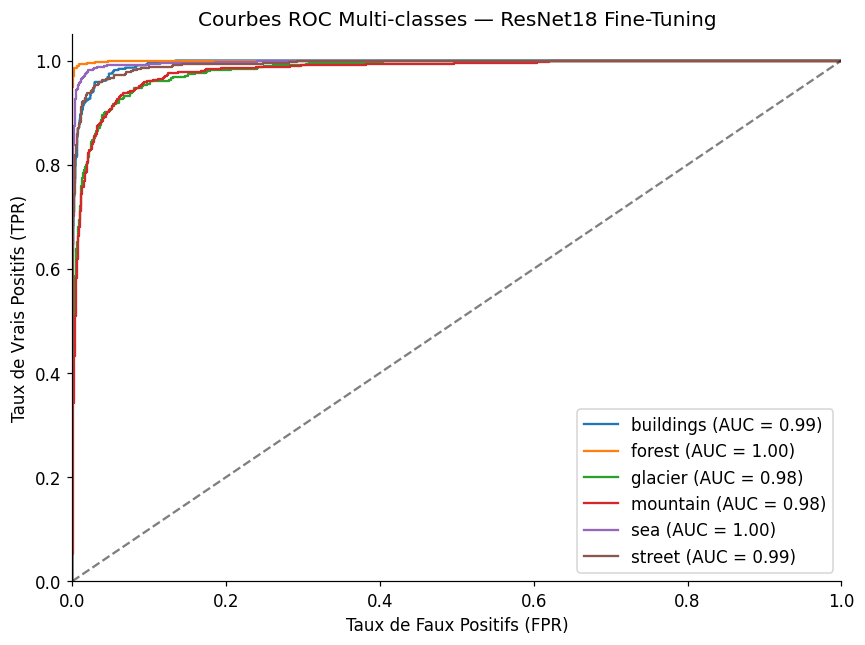

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# EXPÉRIENCE 2 : ResNet18 Fine-Tuning (backbone dégelé, LR différentiel)
# ─────────────────────────────────────────────────────────────────────────
print("\n=== ENTRAÎNEMENT : RESNET18 FINE-TUNING (backbone dégelé) ===\n")
print("LR backbone : 1e-4  |  LR tête : 1e-3\n")

resnet_net  = ResNetFineTune(num_classes=len(classes))
lit_resnet  = LitIntelClassifier(
    resnet_net,
    num_classes=len(classes),
    lr=1e-3,           # LR tête de classification
    lr_backbone=1e-4,  # LR réduit pour le backbone pré-entraîné
    weight_decay=1e-4
)

trainer_resnet = train_model(lit_resnet, "ResNet18_FineTune", train_loader, val_loader, max_epochs=25)

# Courbes d'apprentissage
plot_learning_curves(trainer_resnet, model_name="ResNet18 Fine-Tuning")

# Évaluation sur le jeu de test
print("\n→ Évaluation finale sur le jeu de TEST :")
preds_rn, targets_rn, probs_rn = evaluate_and_interpret(lit_resnet, test_loader, classes, "ResNet18 Fine-Tuning")


Image test — classe réelle : buildings


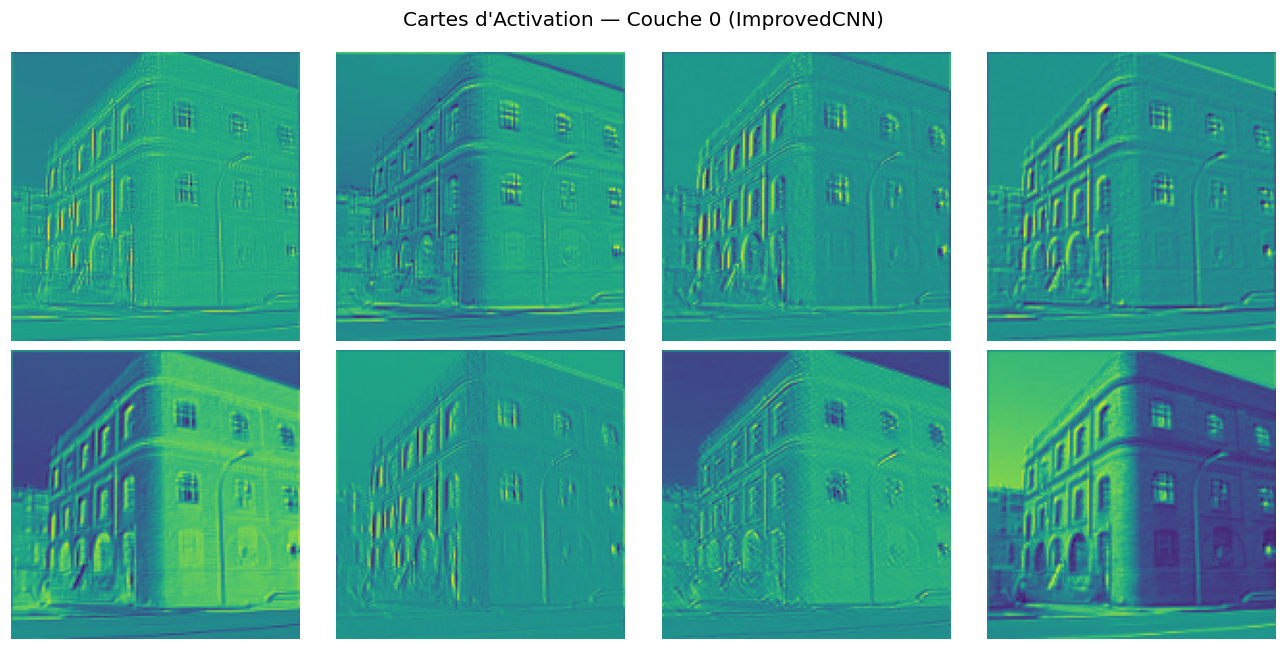

In [16]:
# ─────────────────────────────────────────────────────────────────────────
# Visualisation des cartes d'activation (ImprovedCNN)
# ─────────────────────────────────────────────────────────────────────────
sample_img, sample_label = test_set[0]
print(f"Image test — classe réelle : {classes[sample_label]}")
plot_feature_maps(cnn_net, sample_img, layer_index=0)



=== TABLEAU COMPARATIF FINAL ===
                    Modèle Test Accuracy Macro F1-Score Paramètres totaux             Backbone gelé
ImprovedCNN (from scratch)        0.6827         0.6521           423,046                       N/A
    ResNet18 (Fine-Tuning)        0.8987         0.8999        11,309,382 Non (fine-tuning complet)


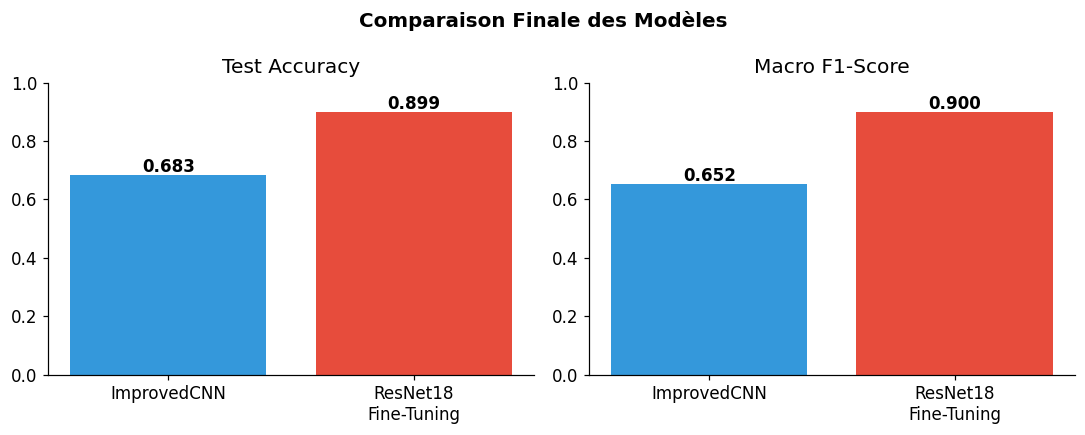

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Comparaison finale des deux modèles
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

acc_cnn    = accuracy_score(targets_cnn, preds_cnn)
acc_resnet = accuracy_score(targets_rn,  preds_rn)
f1_cnn     = f1_score(targets_cnn, preds_cnn, average='macro')
f1_resnet  = f1_score(targets_rn,  preds_rn,  average='macro')

params_cnn    = sum(p.numel() for p in cnn_net.parameters())
params_resnet = sum(p.numel() for p in resnet_net.parameters())

summary = pd.DataFrame({
    "Modèle":            ["ImprovedCNN (from scratch)", "ResNet18 (Fine-Tuning)"],
    "Test Accuracy":     [f"{acc_cnn:.4f}", f"{acc_resnet:.4f}"],
    "Macro F1-Score":    [f"{f1_cnn:.4f}",  f"{f1_resnet:.4f}"],
    "Paramètres totaux": [f"{params_cnn:,}", f"{params_resnet:,}"],
    "Backbone gelé":     ["N/A", "Non (fine-tuning complet)"],
})

print("\n=== TABLEAU COMPARATIF FINAL ===")
print(summary.to_string(index=False))

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
models_names = ["ImprovedCNN", "ResNet18\nFine-Tuning"]

ax1.bar(models_names, [acc_cnn, acc_resnet], color=['#3498db', '#e74c3c'])
ax1.set_title("Test Accuracy")
ax1.set_ylim(0, 1)
for i, v in enumerate([acc_cnn, acc_resnet]):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(models_names, [f1_cnn, f1_resnet], color=['#3498db', '#e74c3c'])
ax2.set_title("Macro F1-Score")
ax2.set_ylim(0, 1)
for i, v in enumerate([f1_cnn, f1_resnet]):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle("Comparaison Finale des Modèles", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()
